# Loading libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
import joblib


# Loading dataset

In [2]:
df= pd.read_csv(r"dataset\AirPassengers.csv")

In [3]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [5]:
# Setting and sorting index
df.set_index('Month', inplace=True)
df.index= pd.to_datetime(df.index)
df.sort_index(inplace=True)

In [6]:
df.index.dtype

dtype('<M8[ns]')

In [7]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [8]:
# Setting frequency 
df=df.asfreq('MS')

In [9]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [10]:
df.shape

(144, 1)

In [11]:
# Checking for null
df.isnull().sum()

#Passengers    0
dtype: int64

In [12]:
# Checking for duplicates
df.duplicated().sum()

np.int64(26)

In [13]:
# Handling Duplicates
df.drop_duplicates(keep='first', inplace=True)

# Exploratory Data Analysis

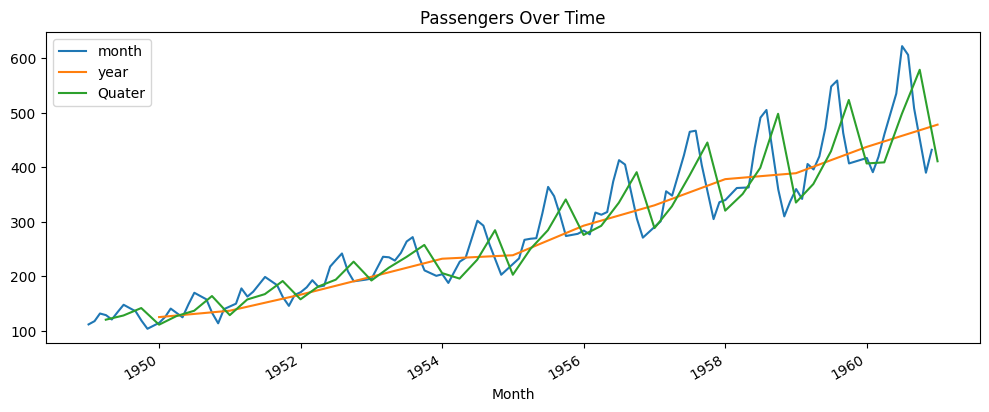

In [14]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='month')
df['#Passengers'].resample('YE').mean().plot(label='year')
df['#Passengers'].resample('QE').mean().plot(label='Quater')


plt.tight_layout()
plt.legend(loc='best')
plt.title('Passengers Over Time')
plt.show()

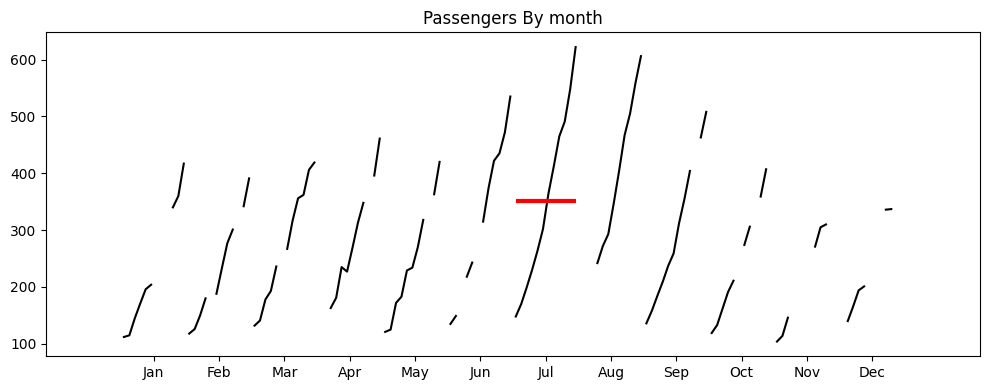

In [15]:

month_plot(df['#Passengers'].resample('ME').mean()).set_size_inches(10,4)

plt.title('Passengers By month')
plt.tight_layout()
plt.show()

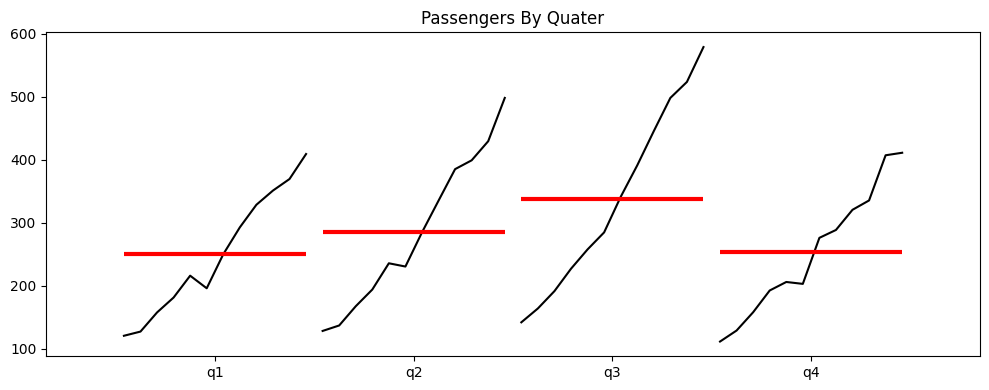

In [16]:
quarter_plot(df['#Passengers'].resample('QE').mean()).set_size_inches(10,4)

plt.title('Passengers By Quater')
plt.tight_layout()
plt.show()

In [17]:
decompose= seasonal_decompose(df['#Passengers'], model='mul',period=12)

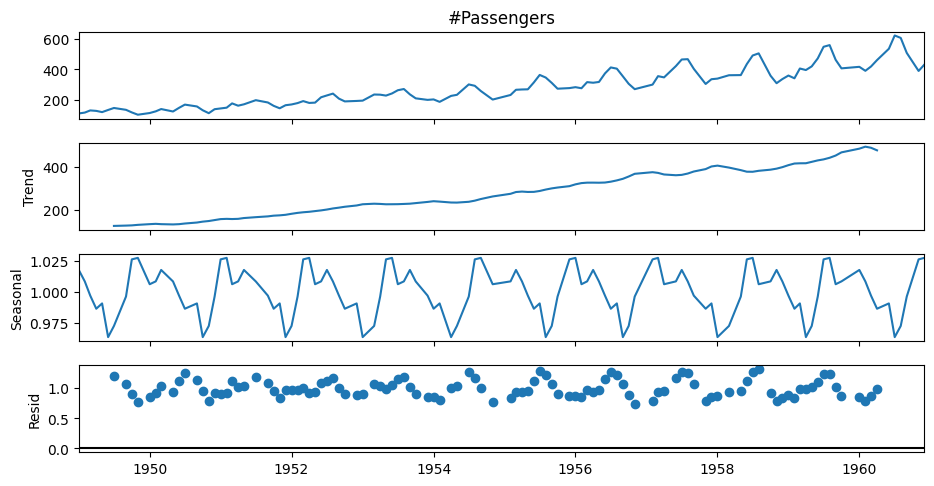

In [18]:

decompose.plot().set_size_inches(10,5)

plt.show()

### Reading the ACF / PACF plots

- The **ACF** plot shows strong, slowly-decaying correlation at seasonal lags (12, 24, 36...), confirming the yearly seasonality already visible in the decomposition above.
- The **PACF** plot shows a sharp cutoff after a small number of lags, which is the classic signature of an autoregressive (AR) component — this is a useful sanity check before letting `auto_arima` search over `(p, d, q)`.

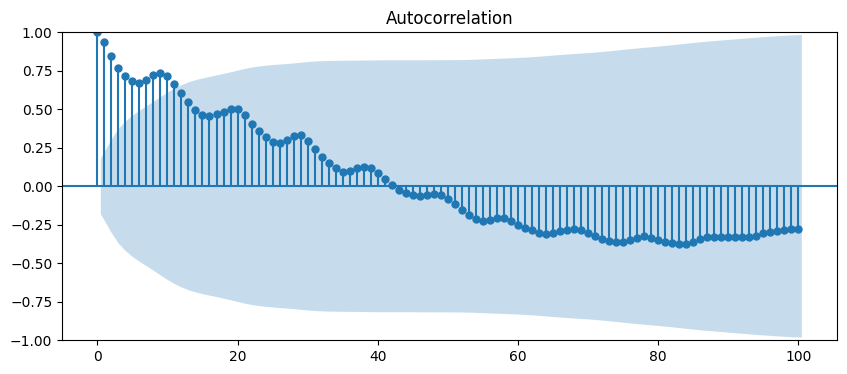

In [19]:
plot_acf(df['#Passengers'], lags=100).set_size_inches(10,4)

plt.show()

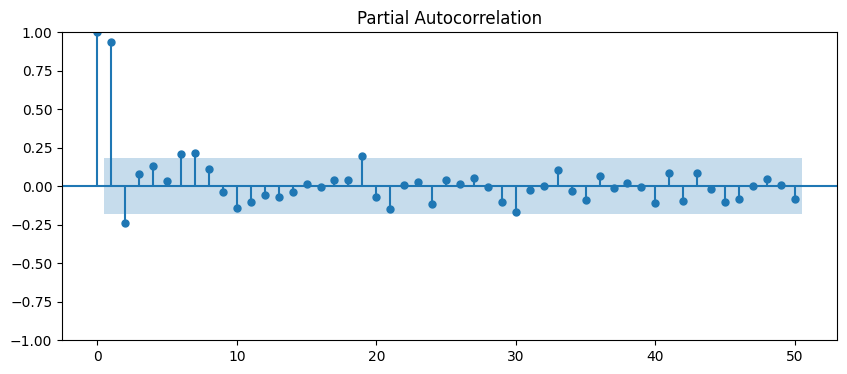

In [20]:
plot_pacf(df['#Passengers'], lags=50).set_size_inches(10,4)

plt.show()

# Stationarity

`adfuller` - used to perform the Augmented Dickey-Fuller test, which is a statistical test for testing the stationarity of a time series

 Stationarity implies that the statistical properties of the time series, such as mean and variance, do not change over time.

 The test evaluates a null hypothesis that the time series is non-stationary. If the p-value obtained from the test is less than a significance level (commonly 0.05), we reject the null hypothesis and conclude that the time series is stationary.

In [21]:

# Perform Augmented Dickey-Fuller test
# 'result' contains the test statistic and the p-value.
def stationarity_test(col):
  result = adfuller(col)
  print('p-value: %f' % result[1])

  # Interpreting the results
  if result[1] < 0.05:
      print("Evidence suggests that the time series is stationary.")
  else:
      print("Evidence suggests that the time series is not stationary.")


In [22]:
stationarity_test(df['#Passengers'].ffill())

p-value: 0.994591
Evidence suggests that the time series is not stationary.


In [23]:

# this is what auto_arima's d=1 is doing under the hood in the SARIMAX notebook
stationarity_test(df['#Passengers'].diff().bfill())

# And after a seasonal difference (lag 12), given the strong yearly seasonality
stationarity_test(df['#Passengers'].diff(12).bfill())

p-value: 0.000000
Evidence suggests that the time series is stationary.
p-value: 0.030398
Evidence suggests that the time series is stationary.


In [24]:
# Performing feature engineering to add more features

def feature_engineering(data):
  data['month']= data.index.month
  data['quater']= data.index.quarter

  for i in [1,2,3,6,12]:
    data[f'lag{i}']= data['#Passengers'].shift(i)
  for i in [3,6,12]:
    data[f'rolling_mean{i}']= data['#Passengers'].rolling(window= i).mean()
    data[f'rolling_std{i}']= data['#Passengers'].rolling(window= i).std()
  return data


### Why these features

- **`month` / `quarter`** — capture the calendar-driven seasonality directly, useful for the SARIMAX exogenous inputs later.
- **Lags (1, 2, 3, 6, 12)** — lag 1-3 capture short-term momentum, lag 6 captures half-year cyclicality, lag 12 captures the dominant yearly seasonal pattern confirmed by the ACF plot above.
- **Rolling mean/std (3, 6, 12)** — smooth out month-to-month noise and give the model a sense of the local trend level and volatility at multiple time horizons.

In [25]:
df= feature_engineering(df)

In [26]:
df.sample(5)

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1955-08-01,347,8,3,364.0,315.0,270.0,233.0,227.0,342.000000,24.879711,305.333333,43.149353,279.666667,47.200411
1952-10-01,191,10,4,209.0,242.0,230.0,181.0,162.0,214.000000,25.865034,212.166667,22.586869,192.500000,27.776707
1956-09-01,355,9,3,405.0,413.0,374.0,317.0,347.0,391.000000,31.432467,363.000000,42.365080,326.666667,49.205198
1952-07-01,230,7,3,218.0,183.0,181.0,171.0,172.0,210.333333,24.419937,197.500000,21.379897,184.416667,23.399527
1953-05-01,229,5,2,235.0,236.0,196.0,209.0,193.0,233.333333,3.785939,213.500000,21.915748,212.000000,22.332203


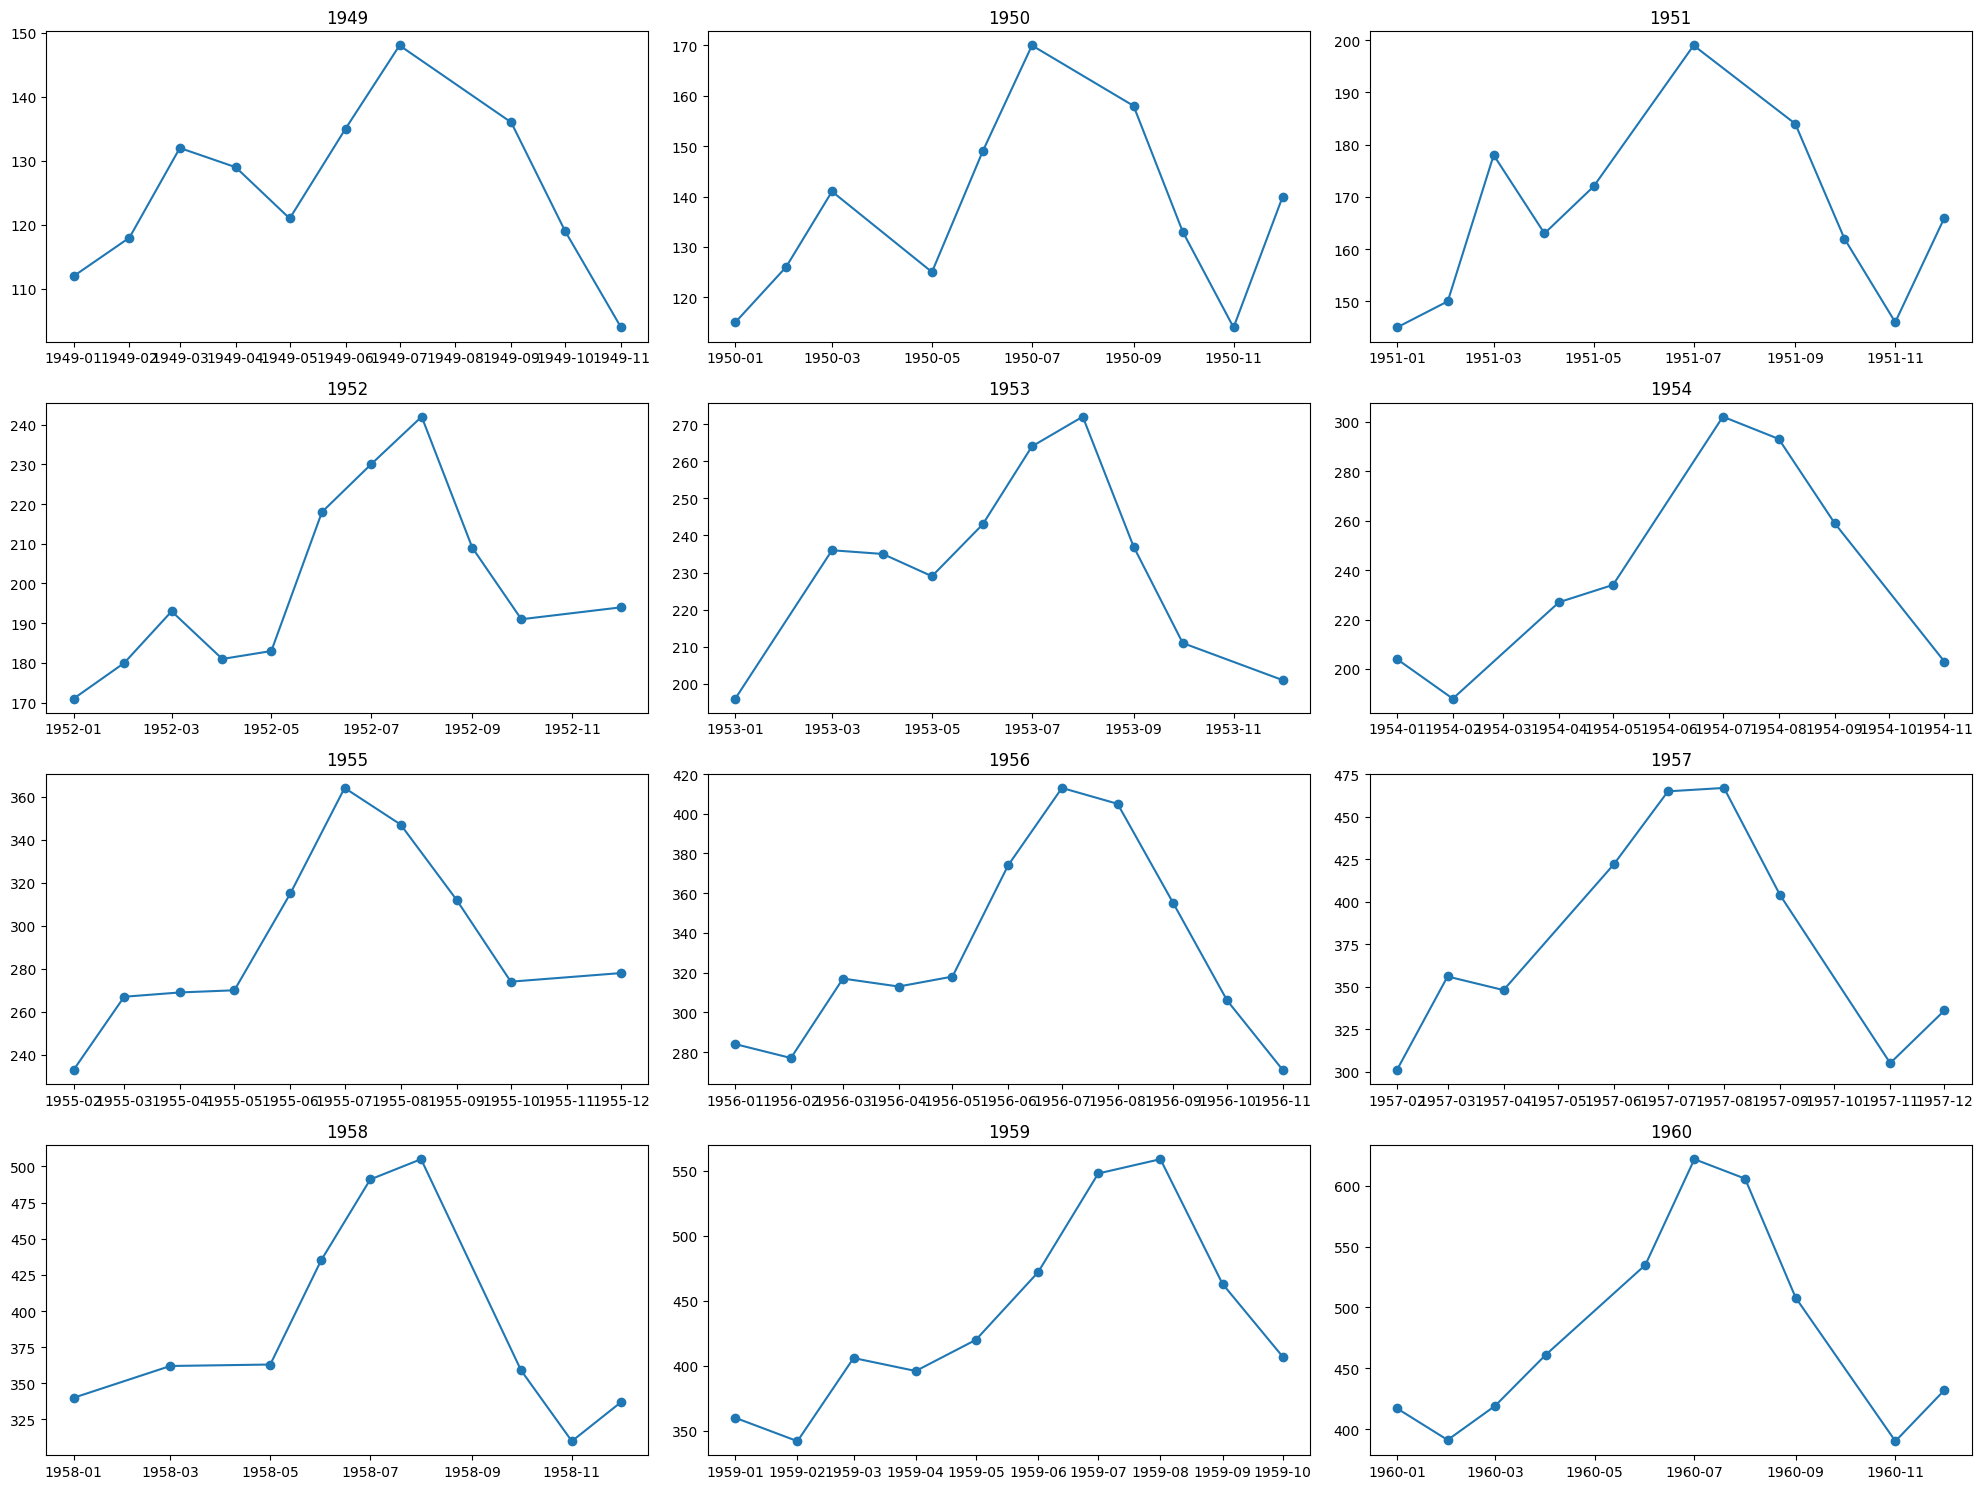

In [27]:
fig, axes= plt.subplots(4,3, figsize=(20,15))
axes= axes.reshape(-1)

for i,year in enumerate(['1949','1950','1951','1952','1953','1954','1955','1956','1957','1958','1959','1960']):
  axes[i].plot(df['#Passengers'].loc[year], marker='o')
  axes[i].set_title(year)

plt.tight_layout()
plt.show()

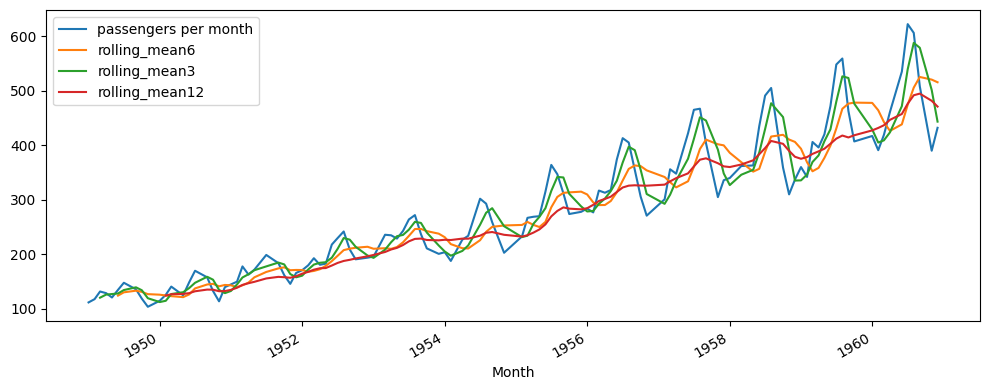

In [29]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='passengers per month')
df['rolling_mean6'].plot(legend=True)
df['rolling_mean3'].plot(legend=True)
df['rolling_mean12'].plot(legend=True)


plt.tight_layout()
plt.legend(loc='best')
plt.show()

In [30]:
joblib.dump(df,r'dataset\df.pkl')

['dataset\\df.pkl']